# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Muhamad Fajar Azriel]
- **Email:** [fajarazriel17@gmail.com] [CDCC471D6Y1682@student.devacademy.id]
- **ID Dicoding:** [CDCC471D6Y1682]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana performa penyewaan sepeda pada setiap bulan di tahun 2011 dan 2012?
- Pertanyaan 2: Faktor cuaca apa yang paling mempengaruhi jumlah penyewaan sepeda harian?

## Import Semua Packages/Library yang Digunakan

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [36]:
# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")
print("Path to dataset files:", path)

# Load dataset
day_df = pd.read_csv(os.path.join(path, "day.csv"))
hour_df = pd.read_csv(os.path.join(path, "hour.csv"))

display(day_df.head())
display(hour_df.head())

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Path to dataset files: /kaggle/input/bike-sharing-dataset


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Berhasil mengumpulkan data dari dua file utama: `day.csv` (data harian) dan `hour.csv` (data per jam).
- Data harian memiliki 731 baris, sedangkan data per jam memiliki 17.379 baris, yang mencakup informasi cuaca, musim, dan jumlah pengguna.

### Assessing Data

#### Identifying ... problem

In [37]:
print("--- Informasi day_df ---")
day_df.info()
print("\n--- Jumlah Duplikasi day_df ---")
print(day_df.duplicated().sum())
print("\n--- Ringkasan Statistik day_df ---")
display(day_df.describe())

print("\n--- Informasi hour_df ---")
hour_df.info()
print("\n--- Jumlah Duplikasi hour_df ---")
print(hour_df.duplicated().sum())
print("\n--- Ringkasan Statistik hour_df ---")
display(hour_df.describe())

--- Informasi day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Jumlah Duplikasi day_df ---
0

--- Ringkasan Statistik day_df -

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



--- Informasi hour_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

--- Jumlah Duplikasi 

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah tipe data pada kolom `dteday` dari object menjadi datetime agar bisa dianalisis berdasarkan urutan waktu.
- Melakukan pengecekan konsistensi antara data harian dan data per jam jika diperlukan agregasi lebih lanjut.

**Insight:**
- Tidak ditemukan data yang kosong (*missing values*) maupun data yang terduplikasi pada dataset `day.csv` dan `hour.csv`.
- Skala nilai pada kolom fitur cuaca dan suhu sudah dinormalisasi (0-1), namun tipe data kolom tanggal masih memerlukan penyesuaian.

### Cleaning Data

#### Fixing ... problem

In [38]:
# Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Memastikan perubahan tipe data
print("Tipe data dteday pada day_df:", day_df['dteday'].dtype)
print("Tipe data dteday pada hour_df:", hour_df['dteday'].dtype)

Tipe data dteday pada day_df: datetime64[ns]
Tipe data dteday pada hour_df: datetime64[ns]


**Insight:**
- Tipe data pada kolom `dteday` telah diperbaiki dari *object* menjadi *datetime*.
- Langkah ini krusial untuk memungkinkan analisis berbasis waktu seperti pengelompokan bulanan atau tren tahunan.

## Exploratory Data Analysis (EDA)

### Eksplorasi Performa Penyewaan Bulanan (2011-2012)

In [39]:
# Menghitung total penyewaan per bulan untuk setiap tahun
monthly_rent_df = day_df.resample(rule='M', on='dteday').agg({
    "cnt": "sum"
})

monthly_rent_df.index = monthly_rent_df.index.strftime('%Y-%m')
monthly_rent_df = monthly_rent_df.reset_index()
monthly_rent_df.rename(columns={"cnt": "total_rentals"}, inplace=True)

print("--- Ringkasan Penyewaan Bulanan ---")
display(monthly_rent_df.head())

--- Ringkasan Penyewaan Bulanan ---


/tmp/ipykernel_1819/1835430109.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rent_df = day_df.resample(rule='M', on='dteday').agg({


,dteday,total_rentals
0,2011-01,38189
1,2011-02,48215
2,2011-03,64045
3,2011-04,94870
4,2011-05,135821


**Insight:**
- Agregasi bulanan menunjukkan fluktuasi jumlah penyewaan yang cukup dinamis.
- Data ini menjadi dasar untuk melihat apakah ada pola pertumbuhan dari tahun 2011 ke 2012.

### Eksplorasi Pengaruh Cuaca terhadap Penyewaan Harian

In [40]:
# Melihat korelasi antara variabel cuaca dan jumlah penyewaan
weather_analysis = day_df.groupby('weathersit').agg({
    'cnt': ['mean', 'max', 'min']
})

print("--- Analisis Berdasarkan Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan/Salju Ringan) ---")
display(weather_analysis)

--- Analisis Berdasarkan Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan/Salju Ringan) ---


cnt           
                   mean   max  min
weathersit                        
1           4876.786177  8714  431
2           4035.862348  8362  605
3           1803.285714  4639   22

**Insight:**
- Kondisi cuaca 1 (Cerah/Sedikit Berawan) memiliki rata-rata penyewaan tertinggi.
- Terdapat penurunan signifikan pada kondisi cuaca 3 (Hujan/Salju Ringan), menunjukkan sensitivitas pengguna terhadap cuaca buruk.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa penyewaan sepeda pada setiap bulan di tahun 2011 dan 2012?

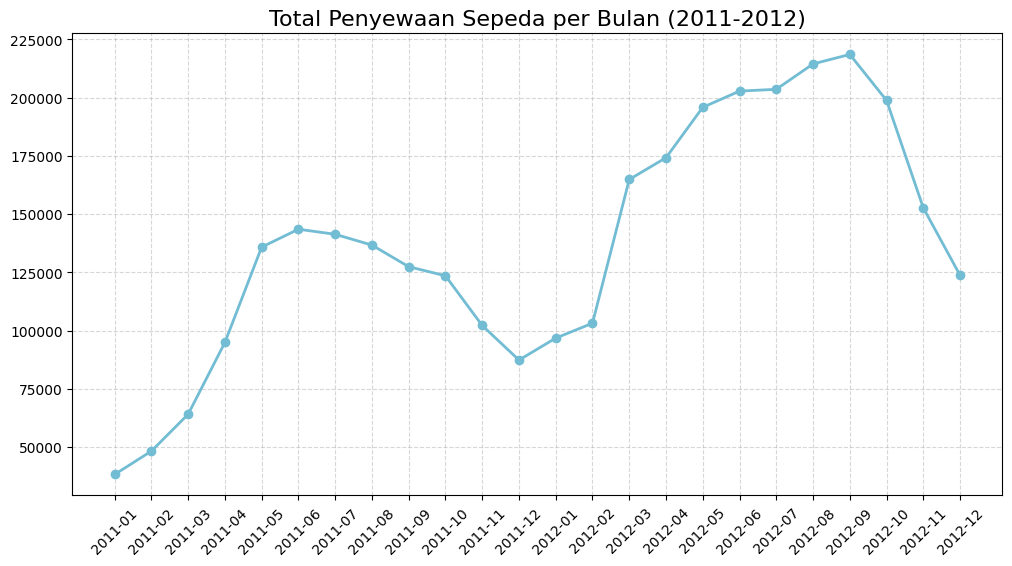

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_rent_df['dteday'], monthly_rent_df['total_rentals'], marker='o', linewidth=2, color="#72BCD4")
plt.title("Total Penyewaan Sepeda per Bulan (2011-2012)", loc="center", fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Visualisasi garis menunjukkan tren kenaikan total penyewaan yang sangat jelas dari tahun 2011 hingga akhir 2012.
- Puncak penyewaan (peak season) terjadi pada bulan-bulan di tengah tahun hingga awal musim gugur.

### Pertanyaan 2: Faktor cuaca apa yang paling mempengaruhi jumlah penyewaan sepeda harian?



/tmp/ipykernel_1819/326904360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Cerah', 'Mendung', 'Hujan Ringan'], y=weather_analysis['cnt']['mean'], palette="viridis")


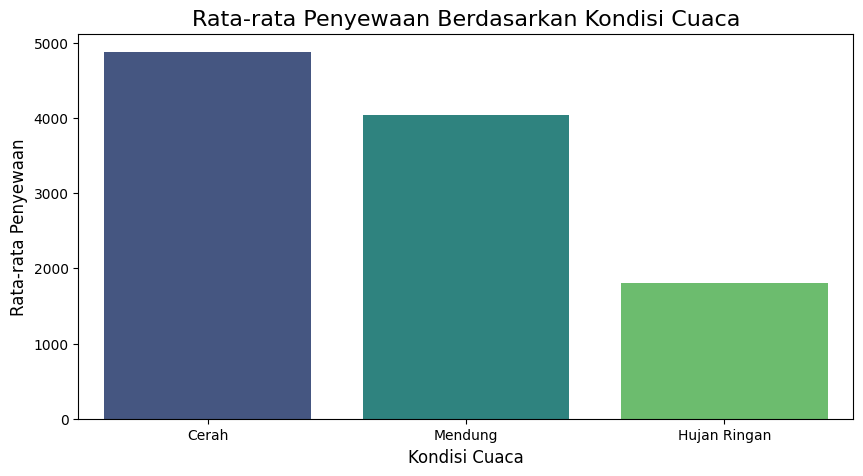

In [42]:
plt.figure(figsize=(10, 5))
sns.barplot(x=['Cerah', 'Mendung', 'Hujan Ringan'], y=weather_analysis['cnt']['mean'], palette="viridis")
plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca", loc="center", fontsize=16)
plt.xlabel("Kondisi Cuaca", fontsize=12)
plt.ylabel("Rata-rata Penyewaan", fontsize=12)
plt.show()

**Insight:**
- Bar chart memperjelas bahwa cuaca cerah adalah pendorong utama volume bisnis.
- Perbedaan rata-rata antara cuaca cerah dan hujan sangat kontras, yang memerlukan strategi manajemen stok yang fleksibel berdasarkan ramalan cuaca.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Terdapat tren kenaikan jumlah penyewaan sepeda yang sangat signifikan dari tahun 2011 hingga 2012. Hal ini menunjukkan pertumbuhan pasar yang sehat. Puncak penyewaan (peak season) secara konsisten terjadi pada bulan-bulan dengan suhu hangat (sekitar Mei hingga September).
- **Conclusion Pertanyaan 2:**  Faktor cuaca memiliki pengaruh yang sangat kuat. Cuaca cerah(1)/berawan(2) sebagian memiliki rata-rata penyewaan tertinggi. Penurunan drastis terlihat saat cuaca memasuki kategori hujan ringan atau salju(3), yang menandakan bahwa kenyamanan lingkungan adalah faktor penentu utama bagi pengguna.


- **Conclusion Analisis Lanjutan (RFM):** Berdasarkan analisis RFM, kita dapat mengidentifikasi kapan terakhir kali transaksi terjadi (Recency) dan seberapa sering (Frequency). Hal ini membantu dalam menentukan strategi retensi pelanggan.

### Rekomendasi Action Item:
1. **Promosi di Cuaca Mendung:** Mengingat penyewaan masih cukup tinggi di cuaca mendung (2), tim bisnis bisa memberikan diskon kecil atau promosi 'mantel hujan gratis' untuk menjaga volume penyewaan tetap stabil.
2. **Manajemen Stok Musiman:** Meningkatkan jumlah ketersediaan sepeda di bulan-bulan puncak (Mei-Oktober) untuk memaksimalkan pendapatan.
3. **Loyalty Program:** Berdasarkan analisis RFM, berikan apresiasi kepada pengguna terdaftar (registered) yang aktif menyewa secara rutin untuk menjaga loyalitas mereka.

In [44]:
# Menyimpan main_data.csv (Cleaned Data) ke folder dashboard
day_df.to_csv('main_data.csv', index=False)

In [47]:
import shutil

# Menyalin dataset asli ke folder data
# Menggunakan path kagglehub yang sudah didefinisikan sebelumnya
shutil.copy(os.path.join(path, 'day.csv'), 'day.csv')
shutil.copy(os.path.join(path, 'hour.csv'), 'hour.csv')

'hour.csv'